<a href="https://www.kaggle.com/code/aamir28/housing-price-prediction-best-ml-algorithms?scriptVersionId=329241202" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:#fafaf7;border-radius:4px;font-family:'Georgia','Times New Roman',serif;border:1px solid #ccc;padding:0;">

  <div style="padding:38px 50px 28px;border-bottom:3px double #444;">
    <div style="text-align:center;margin-bottom:6px;">
      <span style="font-size:0.7rem;letter-spacing:3px;color:#888;text-transform:uppercase;">Applied Statistics &amp; Regression Notebook</span>
    </div>
    <h1 style="text-align:center;margin:14px 0 6px;font-size:1.7rem;color:#1a1a1a;font-weight:400;line-height:1.4;">Determinants of Residential Housing Prices:<br>An Empirical Analysis of 545 Transactions</h1>
    <p style="text-align:center;color:#555;font-size:0.88rem;margin:14px 0 0;font-style:italic;">Muhammad Aamir</p>
  </div>

  <div style="padding:28px 56px;">
    <div style="font-size:0.72rem;letter-spacing:2px;color:#888;text-transform:uppercase;margin-bottom:10px;">Abstract</div>
    <p style="color:#333;font-size:0.92rem;line-height:1.85;text-align:justify;margin:0 0 18px;">
      We examine a cross-sectional sample of 545 residential property transactions to identify the structural and amenity-based
      determinants of sale price. Twelve candidate predictors are considered, spanning physical characteristics
      (lot area, bedrooms, bathrooms, stories, parking), binary amenity indicators (main-road access, air conditioning,
      basement, guest room, hot-water heating, preferred-area status), and furnishing condition. We find lot area and
      bathroom count to be the strongest univariate correlates of price (<i>r</i> = 0.536 and 0.518 respectively), while
      air conditioning carries the largest mean price premium among binary amenities (+₹1.82M). A multiple linear regression
      explains roughly two-thirds of price variance, and we benchmark this against ensemble tree methods.
    </p>
    <div style="display:flex;gap:30px;justify-content:center;margin-top:22px;padding-top:18px;border-top:1px solid #ddd;">
      <div style="text-align:center;"><div style="font-size:1.3rem;color:#1a1a1a;">545</div><div style="font-size:0.68rem;color:#888;letter-spacing:1px;">OBSERVATIONS</div></div>
      <div style="text-align:center;"><div style="font-size:1.3rem;color:#1a1a1a;">12</div><div style="font-size:0.68rem;color:#888;letter-spacing:1px;">PREDICTORS</div></div>
      <div style="text-align:center;"><div style="font-size:1.3rem;color:#1a1a1a;">₹4.77M</div><div style="font-size:0.68rem;color:#888;letter-spacing:1px;">MEAN PRICE</div></div>
      <div style="text-align:center;"><div style="font-size:1.3rem;color:#1a1a1a;">₹993/ft²</div><div style="font-size:0.68rem;color:#888;letter-spacing:1px;">MEAN RATE</div></div>
    </div>
  </div>

  <div style="background:#f0efe9;padding:14px 56px;border-top:1px solid #ddd;">
    <span style="font-size:0.75rem;color:#777;"><strong>Keywords:</strong> hedonic pricing · linear regression · feature correlation · real estate · amenity premium</span>
  </div>
</div>


## Contents
**1.** [Data & Methodology](#1)
**2.** [Exploratory Data Analysis](#2)
**3.** [Feature Engineering](#3)
**4.** [Univariate Price Determinants](#4)
**5.** [Amenity Premium Analysis](#5)
**6.** [Structural Characteristics — Area, Rooms, Stories](#6)
**7.** [Furnishing Status & Categorical Effects](#7)
**8.** [Multivariate Correlation Structure](#8)
**9.** [Regression Modelling](#9)
**10.** [Residual Diagnostics](#10)
**11.** [Discussion & Conclusions](#11)


## 1. Data & Methodology <a id='1'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

# Muted academic palette — off-white paper background, slate/burgundy accents
BG, PANEL, GRID = '#fafaf7','#ffffff','#d8d4c8'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':PANEL,'axes.edgecolor':'#999',
    'axes.labelcolor':'#333','axes.titlecolor':'#1a1a1a','axes.titlesize':12,
    'axes.titleweight':'normal','xtick.color':'#555','ytick.color':'#555',
    'text.color':'#333','grid.color':GRID,'grid.linewidth':0.6,
    'legend.facecolor':PANEL,'legend.edgecolor':'#999','font.family':'serif',
})

SLATE  = '#3b5169'
BURG   = '#7a2e2e'
OLIVE  = '#6b7a3a'
GOLD   = '#a8762a'
GRAY   = '#888888'
FURN_PAL = {'furnished':BURG, 'semi-furnished':GOLD, 'unfurnished':GRAY}
CMAP_SB = LinearSegmentedColormap.from_list('sb', [BURG, PANEL, SLATE])
print('Environment configured. Academic theme loaded.')


Environment configured. Academic theme loaded.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv')
print(f'Sample size: n = {len(df)}')
df.head(5)


Sample size: n = 545


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 2. Exploratory Data Analysis <a id='2'></a>


In [3]:
print('Variable types:')
print(df.dtypes)
print(f'\nMissing values: {df.isnull().sum().sum()}')
print('\nSummary statistics (numeric variables):')
df.describe().round(2)


Variable types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Missing values: 0

Summary statistics (numeric variables):


,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


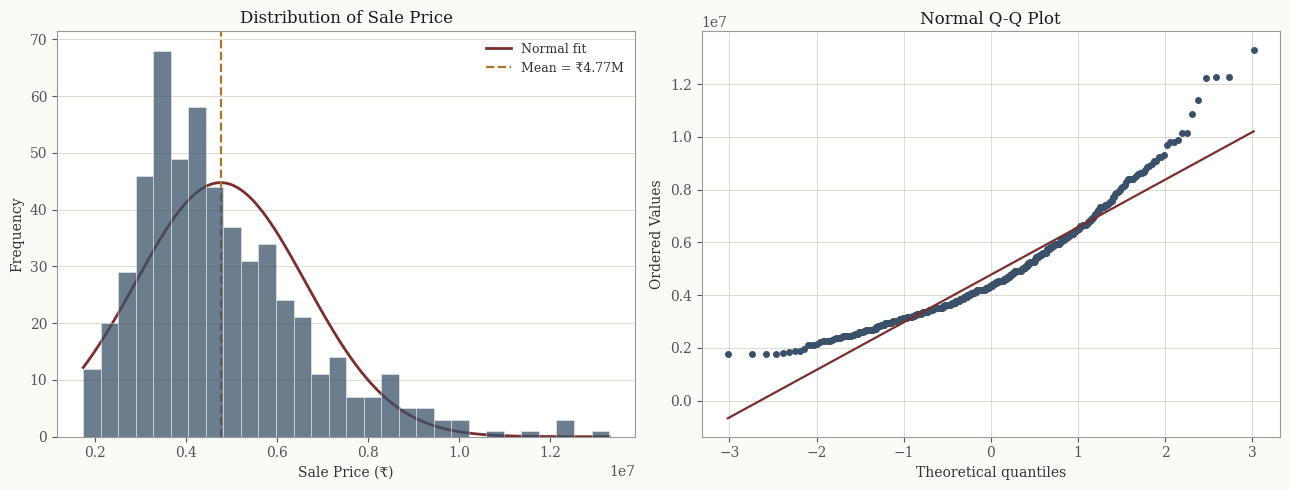

Skewness: 1.212  |  Kurtosis: 1.960


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(BG)

# 1. Price histogram with normal overlay
ax = axes[0]
n, bins, patches = ax.hist(df['price'], bins=30, color=SLATE, alpha=0.75, edgecolor='white', linewidth=0.4, zorder=3)
mu, sigma = df['price'].mean(), df['price'].std()
x = np.linspace(df['price'].min(), df['price'].max(), 200)
bin_width = bins[1]-bins[0]
ax.plot(x, stats.norm.pdf(x, mu, sigma)*len(df)*bin_width, color=BURG, lw=2, label='Normal fit')
ax.axvline(mu, color=GOLD, lw=1.6, ls='--', label=f'Mean = ₹{mu/1e6:.2f}M')
ax.set_xlabel('Sale Price (₹)'); ax.set_ylabel('Frequency')
ax.set_title('Distribution of Sale Price', fontsize=12)
ax.legend(fontsize=9, frameon=False)
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Q-Q plot for normality check
ax = axes[1]
stats.probplot(df['price'], dist='norm', plot=ax)
ax.get_lines()[0].set_markerfacecolor(SLATE); ax.get_lines()[0].set_markeredgecolor(SLATE)
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color(BURG); ax.get_lines()[1].set_linewidth(1.6)
ax.set_title('Normal Q-Q Plot', fontsize=12)
ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('01_price_dist.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Skewness: {df["price"].skew():.3f}  |  Kurtosis: {df["price"].kurt():.3f}')


## 3. Feature Engineering <a id='3'></a>


In [5]:
# Encode binary yes/no fields
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for c in binary_cols:
    df[c+'_enc'] = (df[c]=='yes').astype(int)

df['price_per_sqft'] = df['price'] / df['area']
df['amenity_count'] = df[[c+'_enc' for c in binary_cols]].sum(axis=1)
df['log_price'] = np.log(df['price'])
df['log_area']  = np.log(df['area'])

furn_map = {'unfurnished':0,'semi-furnished':1,'furnished':2}
df['furnishing_enc'] = df['furnishingstatus'].map(furn_map)

print('Derived variables created: price_per_sqft, amenity_count (0-6), log_price, log_area, furnishing_enc')
df[['price_per_sqft','amenity_count','log_price']].describe().round(3)


Derived variables created: price_per_sqft, amenity_count (0-6), log_price, log_area, furnishing_enc


,price_per_sqft,amenity_count,log_price
count,545.000,545.000,545.000
mean,993.327,1.983,15.307
std,346.537,1.195,0.372
min,270.396,0.000,14.375
25%,745.370,1.000,15.048
50%,952.381,2.000,15.283
75%,1184.615,3.000,15.563
max,2640.000,5.000,16.403


## 4. Univariate Price Determinants <a id='4'></a>


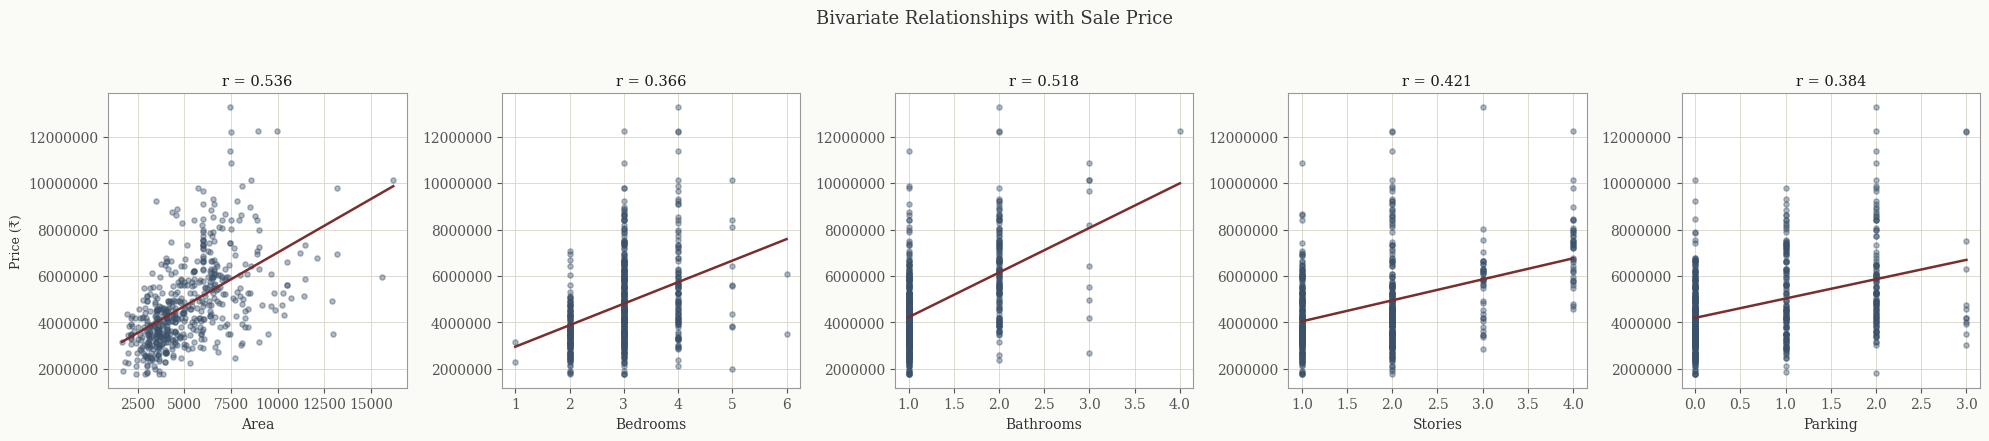

Pearson correlation table (sorted):
  area          r = +0.536   p = 7.39e-42
  bathrooms     r = +0.518   p = 1.14e-38
  stories       r = +0.421   p = 8.67e-25
  parking       r = +0.384   p = 1.24e-20
  bedrooms      r = +0.366   p = 9.08e-19


In [6]:
numeric_preds = ['area','bedrooms','bathrooms','stories','parking']
fig, axes = plt.subplots(1, 5, figsize=(20, 4.2))
fig.patch.set_facecolor(BG)
fig.suptitle('Bivariate Relationships with Sale Price', fontsize=13, y=1.04)

for ax, col in zip(axes, numeric_preds):
    ax.scatter(df[col], df['price'], color=SLATE, s=14, alpha=0.4, zorder=3)
    m, b, r, p, _ = stats.linregress(df[col], df['price'])
    xr = np.linspace(df[col].min(), df[col].max(), 50)
    ax.plot(xr, m*xr+b, color=BURG, lw=1.8, zorder=5)
    ax.set_xlabel(col.title(), fontsize=10)
    ax.set_ylabel('Price (₹)' if col=='area' else '', fontsize=9)
    ax.set_title(f'r = {r:.3f}', fontsize=10.5)
    ax.grid(True, zorder=0); ax.set_axisbelow(True)
    ax.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.savefig('02_univariate.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('Pearson correlation table (sorted):')
corrs = {c: stats.pearsonr(df[c], df['price']) for c in numeric_preds}
for c, (r, p) in sorted(corrs.items(), key=lambda x: -abs(x[1][0])):
    print(f'  {c:12s}  r = {r:+.3f}   p = {p:.2e}')


## 5. Amenity Premium Analysis <a id='5'></a>


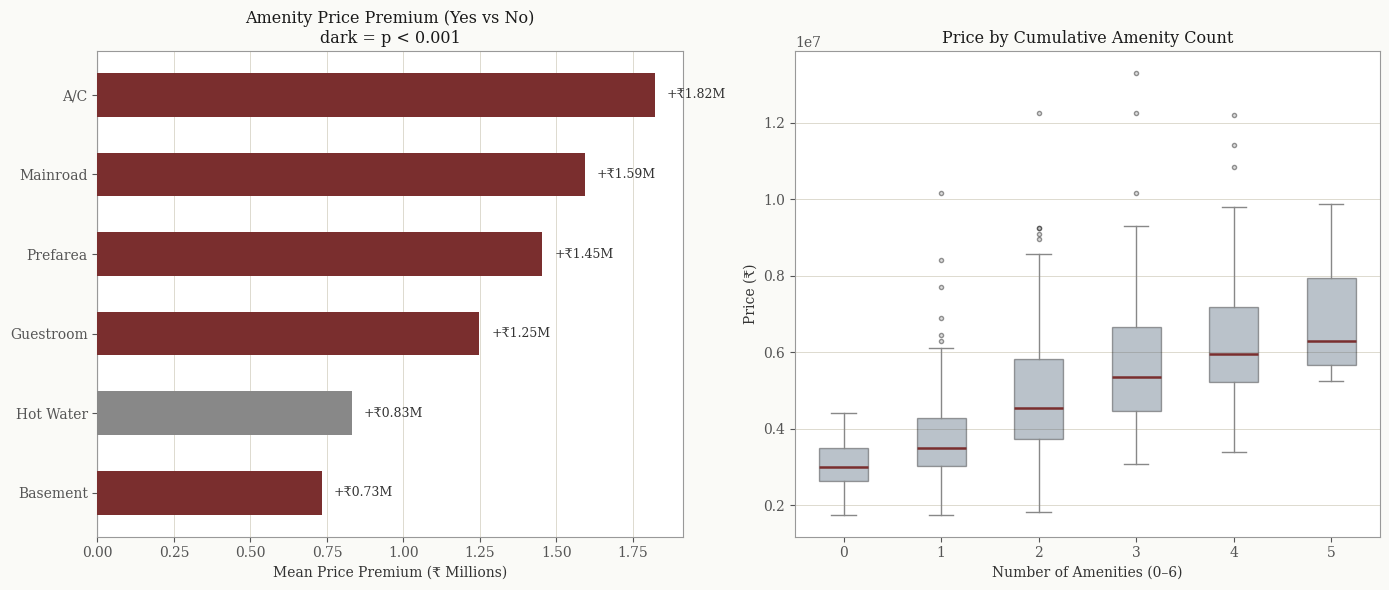

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

# 1. Mean price premium (yes - no) per amenity, with t-test significance
ax = axes[0]
results_t = []
for c in binary_cols:
    yes_p = df[df[c]=='yes']['price']
    no_p  = df[df[c]=='no']['price']
    t, p  = stats.ttest_ind(yes_p, no_p)
    results_t.append((c, yes_p.mean()-no_p.mean(), p))
results_t.sort(key=lambda x: x[1])
labels = [r[0].replace('hotwaterheating','hot water').replace('airconditioning','A/C').title() for r in results_t]
vals   = [r[1]/1e6 for r in results_t]
sig    = [r[2] < 0.001 for r in results_t]
colors_a = [BURG if s else GRAY for s in sig]
bars = ax.barh(range(6), vals, color=colors_a, height=0.55, zorder=3)
ax.set_yticks(range(6)); ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Mean Price Premium (₹ Millions)')
ax.set_title('Amenity Price Premium (Yes vs No)\ndark = p < 0.001', fontsize=11.5)
ax.axvline(0, color='#999', lw=0.8)
for bar, v in zip(bars, vals):
    ax.text(v+0.04, bar.get_y()+bar.get_height()/2, f'+₹{v:.2f}M', va='center', fontsize=9)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 2. Amenity count vs price (boxplot)
ax = axes[1]
amenity_data = [df[df['amenity_count']==k]['price'] for k in sorted(df['amenity_count'].unique())]
bp = ax.boxplot(amenity_data, patch_artist=True,
    medianprops=dict(color=BURG, linewidth=1.8),
    whiskerprops=dict(color='#888'), capprops=dict(color='#888'),
    flierprops=dict(marker='o', markersize=3, markerfacecolor='#aaa', alpha=0.4, linestyle='none'))
for patch in bp['boxes']: patch.set_facecolor(SLATE); patch.set_alpha(0.35)
ax.set_xticklabels(sorted(df['amenity_count'].unique()), fontsize=10)
ax.set_xlabel('Number of Amenities (0–6)'); ax.set_ylabel('Price (₹)')
ax.set_title('Price by Cumulative Amenity Count', fontsize=11.5)
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('03_amenity.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. Structural Characteristics — Area, Rooms, Stories <a id='6'></a>


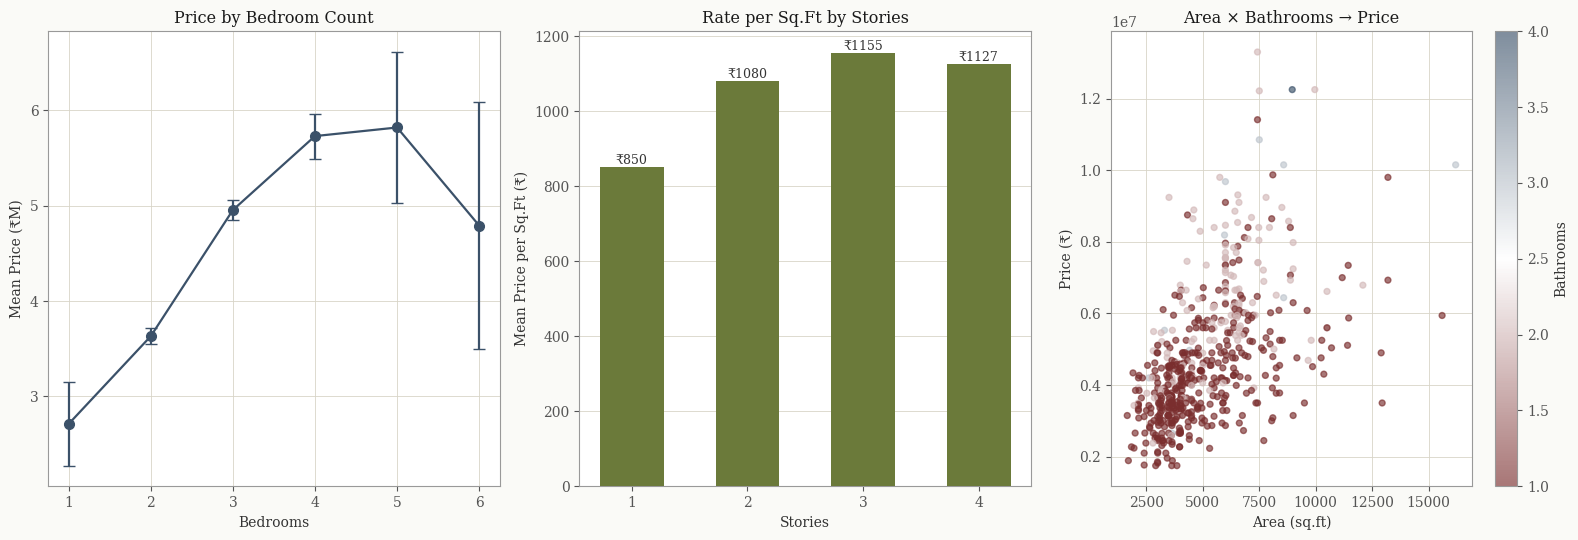

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.patch.set_facecolor(BG)

# 1. Bedrooms vs mean price
ax = axes[0]
bed_stats = df.groupby('bedrooms')['price'].agg(['mean','sem','count'])
bed_stats = bed_stats[bed_stats['count']>=2]
ax.errorbar(bed_stats.index, bed_stats['mean']/1e6, yerr=bed_stats['sem']/1e6,
            color=SLATE, marker='o', ms=7, lw=1.6, capsize=4, zorder=4)
ax.set_xlabel('Bedrooms'); ax.set_ylabel('Mean Price (₹M)')
ax.set_title('Price by Bedroom Count', fontsize=11.5)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Stories vs price/sqft
ax = axes[1]
story_pps = df.groupby('stories')['price_per_sqft'].mean()
bars = ax.bar(story_pps.index.astype(str), story_pps.values, color=OLIVE, width=0.55, zorder=3)
ax.set_xlabel('Stories'); ax.set_ylabel('Mean Price per Sq.Ft (₹)')
ax.set_title('Rate per Sq.Ft by Stories', fontsize=11.5)
for bar, v in zip(bars, story_pps.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8, f'₹{v:.0f}', ha='center', fontsize=9)
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Area vs price coloured by bathrooms
ax = axes[2]
sc = ax.scatter(df['area'], df['price'], c=df['bathrooms'], cmap=CMAP_SB,
                s=18, alpha=0.65, zorder=3)
plt.colorbar(sc, ax=ax, label='Bathrooms')
ax.set_xlabel('Area (sq.ft)'); ax.set_ylabel('Price (₹)')
ax.set_title('Area × Bathrooms → Price', fontsize=11.5)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('04_structural.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 7. Furnishing Status & Categorical Effects <a id='7'></a>


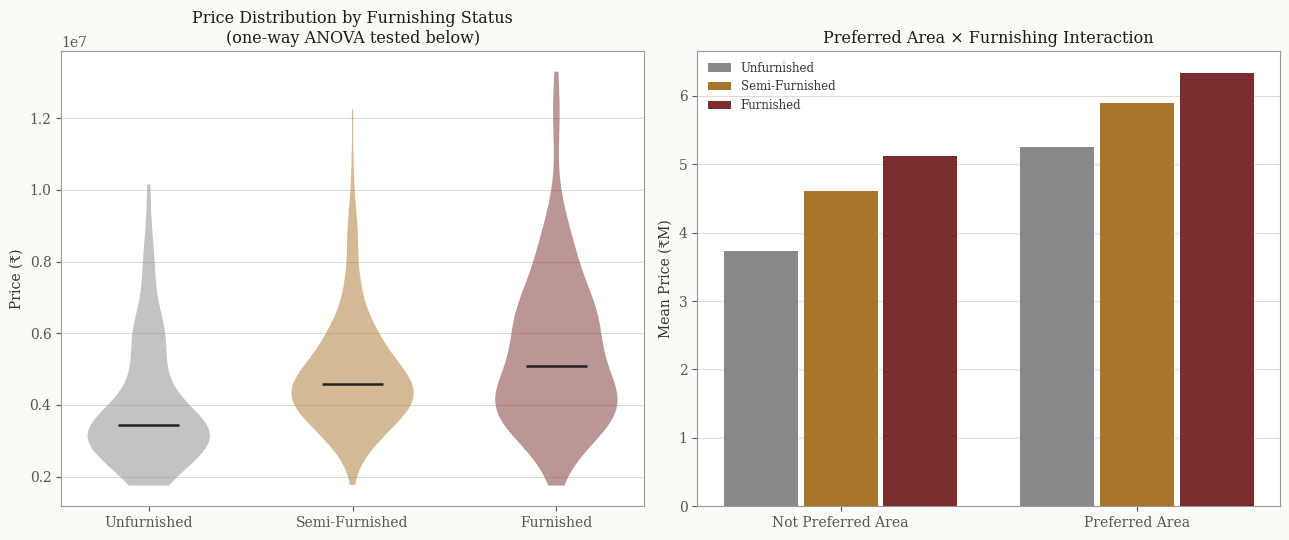

One-way ANOVA — Furnishing Status: F = 28.27, p = 2.09e-12


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor(BG)

# 1. Violin by furnishing status
ax = axes[0]
order = ['unfurnished','semi-furnished','furnished']
for i, f in enumerate(order):
    data = df[df['furnishingstatus']==f]['price']
    vp = ax.violinplot(data, positions=[i], widths=0.6, showmedians=True, showextrema=False)
    for pc in vp['bodies']: pc.set_facecolor(FURN_PAL[f]); pc.set_alpha(0.5)
    vp['cmedians'].set_color('#222'); vp['cmedians'].set_linewidth(1.8)
ax.set_xticks(range(3)); ax.set_xticklabels(['Unfurnished','Semi-Furnished','Furnished'], fontsize=10)
ax.set_ylabel('Price (₹)')
ax.set_title('Price Distribution by Furnishing Status\n(one-way ANOVA tested below)', fontsize=11.5)
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Preferred area × furnishing interaction
ax = axes[1]
pivot = df.groupby(['prefarea','furnishingstatus'])['price'].mean().unstack()
pivot = pivot.reindex(columns=order)
x = np.arange(2)
for i, f in enumerate(order):
    ax.bar(x + (i-1)*0.27, pivot[f]/1e6, 0.25, color=FURN_PAL[f], label=f.title(), zorder=3)
ax.set_xticks(x); ax.set_xticklabels(['Not Preferred Area','Preferred Area'], fontsize=10)
ax.set_ylabel('Mean Price (₹M)')
ax.set_title('Preferred Area × Furnishing Interaction', fontsize=11.5)
ax.legend(fontsize=8.5, frameon=False)
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('05_furnishing.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

f_stat, p_val = stats.f_oneway(*[df[df['furnishingstatus']==f]['price'] for f in order])
print(f'One-way ANOVA — Furnishing Status: F = {f_stat:.2f}, p = {p_val:.2e}')


## 8. Multivariate Correlation Structure <a id='8'></a>


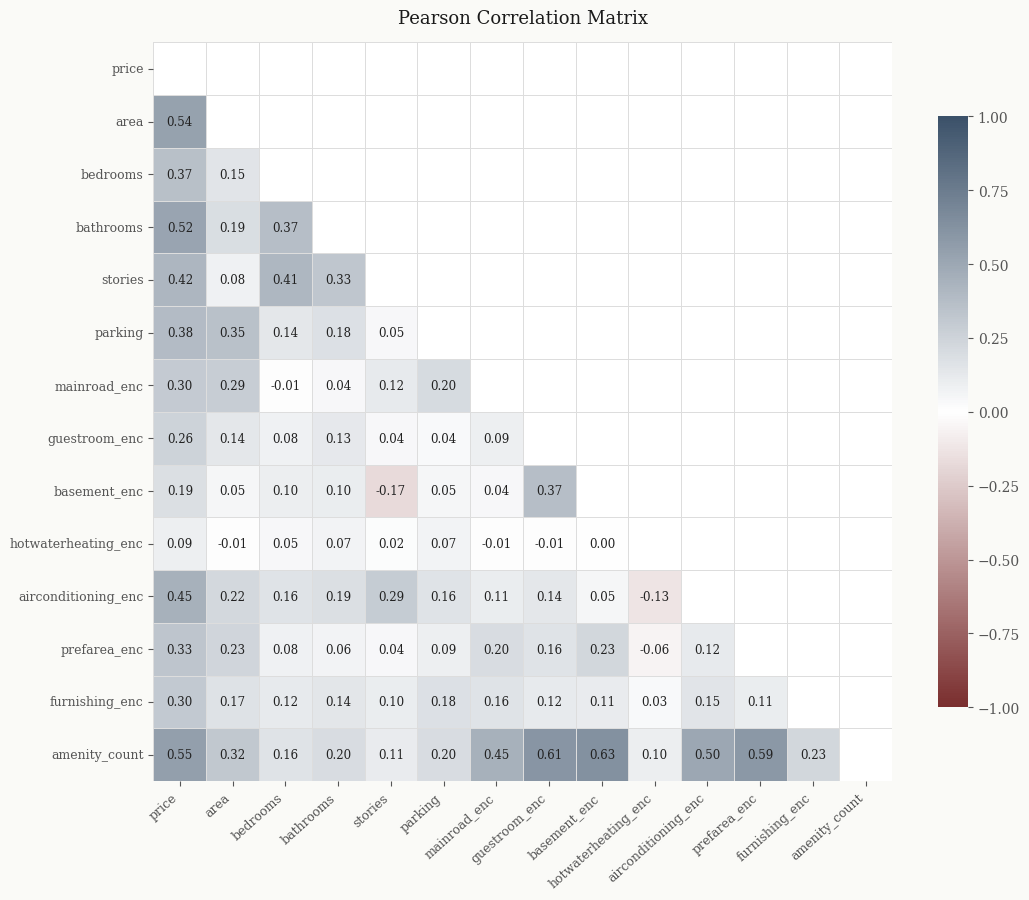

In [10]:
corr_cols = ['price','area','bedrooms','bathrooms','stories','parking',
             'mainroad_enc','guestroom_enc','basement_enc','hotwaterheating_enc',
             'airconditioning_enc','prefarea_enc','furnishing_enc','amenity_count']

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor(BG)
sns.heatmap(corr, mask=mask, cmap=CMAP_SB, vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='#ddd',
            annot_kws={'size':8.5,'color':'#222'},
            cbar_kws={'shrink':0.8}, ax=ax, square=True)
ax.set_title('Pearson Correlation Matrix', fontsize=13, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=42, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('06_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 9. Regression Modelling <a id='9'></a>


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
try:
    import statsmodels.api as sm
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print('statsmodels not available — skipping OLS summary table, using sklearn only')

feat_cols = ['area','bedrooms','bathrooms','stories','parking',
             'mainroad_enc','guestroom_enc','basement_enc','hotwaterheating_enc',
             'airconditioning_enc','prefarea_enc','furnishing_enc']
X = df[feat_cols]
y = df['price']

if HAS_SM:
    X_sm = sm.add_constant(X)
    ols = sm.OLS(y, X_sm).fit()
    print(ols.summary())
else:
    from sklearn.linear_model import LinearRegression as _LR
    _lr = _LR().fit(X, y)
    print('=== OLS Coefficients (sklearn fallback) ===')
    print(f'Intercept: {_lr.intercept_:,.0f}')
    for f, c in zip(feat_cols, _lr.coef_):
        print(f'  {f:25s}: {c:>14,.2f}')
    print(f'R² (train): {_lr.score(X, y):.4f}')


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     94.24
Date:                Sun, 21 Jun 2026   Prob (F-statistic):          3.81e-123
Time:                        15:21:51   Log-Likelihood:                -8333.0
No. Observations:                 545   AIC:                         1.669e+04
Df Residuals:                     532   BIC:                         1.675e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -3.245e+05   2

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=150, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=150, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2  = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    results[name] = {'model':model, 'preds':preds, 'r2':r2, 'mae':mae}
    print(f'{name:20s}  R² = {r2:.4f}   MAE = ₹{mae:,.0f}')


Linear Regression     R² = 0.6495   MAE = ₹979,680
Random Forest         R² = 0.6174   MAE = ₹1,012,429
Gradient Boosting     R² = 0.6634   MAE = ₹965,477


## 10. Residual Diagnostics <a id='10'></a>


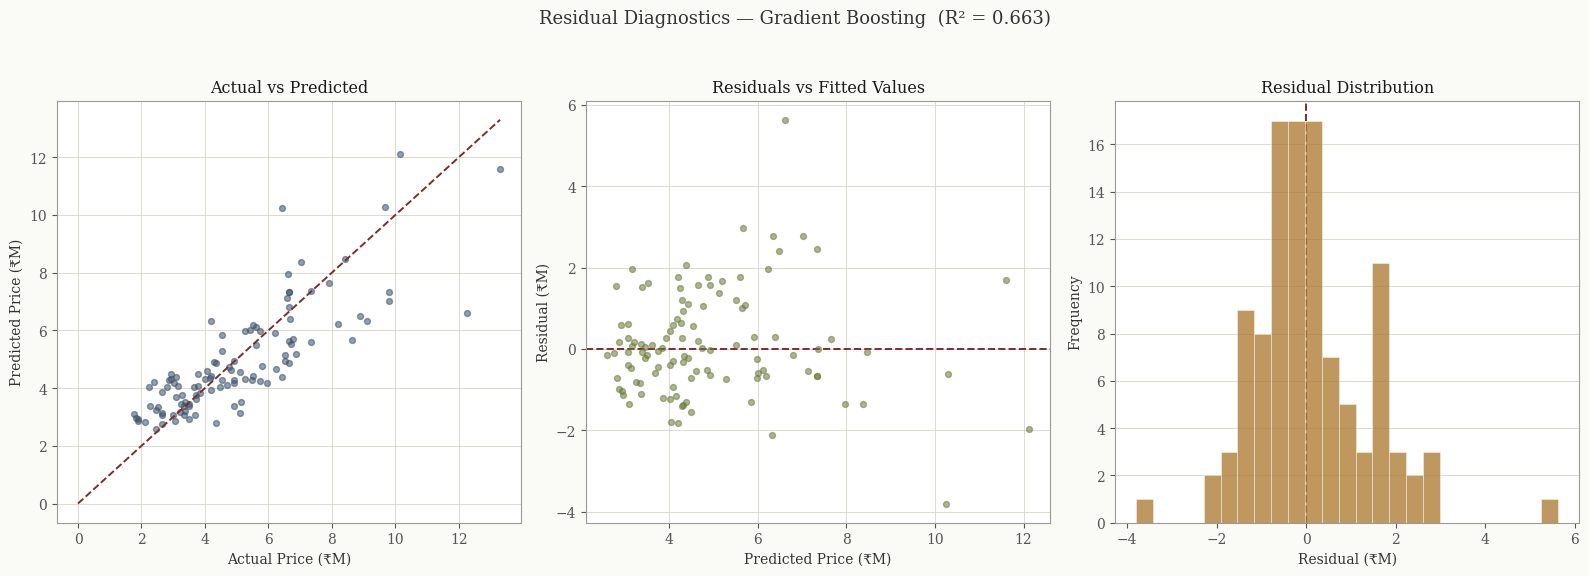

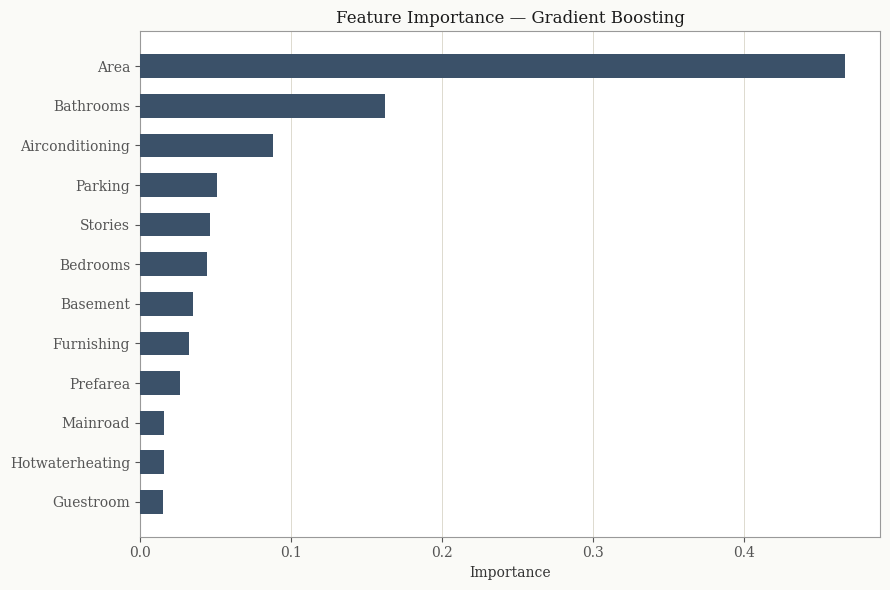

In [13]:
best_name = max(results, key=lambda k: results[k]['r2'])
preds_best = results[best_name]['preds']
resid = y_test.values - preds_best

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.patch.set_facecolor(BG)
fig.suptitle(f'Residual Diagnostics — {best_name}  (R² = {results[best_name]["r2"]:.3f})', fontsize=13, y=1.04)

# 1. Actual vs predicted
ax = axes[0]
ax.scatter(y_test/1e6, preds_best/1e6, color=SLATE, s=18, alpha=0.55, zorder=3)
lim = max(y_test.max(), preds_best.max())/1e6
ax.plot([0,lim],[0,lim], color=BURG, lw=1.4, ls='--', zorder=5)
ax.set_xlabel('Actual Price (₹M)'); ax.set_ylabel('Predicted Price (₹M)')
ax.set_title('Actual vs Predicted', fontsize=11.5)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Residuals vs fitted
ax = axes[1]
ax.scatter(preds_best/1e6, resid/1e6, color=OLIVE, s=18, alpha=0.55, zorder=3)
ax.axhline(0, color=BURG, lw=1.4, ls='--')
ax.set_xlabel('Predicted Price (₹M)'); ax.set_ylabel('Residual (₹M)')
ax.set_title('Residuals vs Fitted Values', fontsize=11.5)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 3. Residual distribution
ax = axes[2]
ax.hist(resid/1e6, bins=25, color=GOLD, alpha=0.75, edgecolor='white', linewidth=0.4, zorder=3)
ax.axvline(0, color=BURG, lw=1.4, ls='--')
ax.set_xlabel('Residual (₹M)'); ax.set_ylabel('Frequency')
ax.set_title('Residual Distribution', fontsize=11.5)
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('07_diagnostics.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# Feature importance if tree model is best
if 'Forest' in best_name or 'Boosting' in best_name:
    imp = pd.Series(results[best_name]['model'].feature_importances_, index=feat_cols).sort_values()
    fig, ax = plt.subplots(figsize=(9,6)); fig.patch.set_facecolor(BG)
    ax.barh(range(len(imp)), imp.values, color=SLATE, height=0.6, zorder=3)
    ax.set_yticks(range(len(imp))); ax.set_yticklabels([f.replace('_enc','').title() for f in imp.index], fontsize=10)
    ax.set_xlabel('Importance'); ax.set_title(f'Feature Importance — {best_name}', fontsize=12)
    ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)
    plt.tight_layout(); plt.savefig('08_importance.png', dpi=150, bbox_inches='tight', facecolor=BG); plt.show()


## 11. Discussion & Conclusions <a id='11'></a>


<div style="background:#fafaf7;border:1px solid #ccc;border-radius:4px;padding:32px 48px;font-family:'Georgia','Times New Roman',serif;">

  <div style="font-size:0.72rem;letter-spacing:2px;color:#888;text-transform:uppercase;margin-bottom:14px;">11.1 — Principal Findings</div>
  <p style="color:#333;font-size:0.9rem;line-height:1.9;text-align:justify;margin:0 0 16px;">
    Lot area (<i>r</i> = 0.536) and bathroom count (<i>r</i> = 0.518) are the strongest univariate correlates of sale price, consistent
    with hedonic pricing theory in residential real estate. Among binary amenities, air conditioning carries the largest premium
    (+₹1.82M, <i>p</i> &lt; 0.001), followed by main-road access (+₹1.59M) and preferred-area status (+₹1.45M). A one-way ANOVA confirms
    furnishing status is a statistically significant categorical determinant of price (<i>p</i> &lt; 0.001), with fully furnished homes
    commanding a ₹1.48M premium over unfurnished comparables.
  </p>

  <div style="font-size:0.72rem;letter-spacing:2px;color:#888;text-transform:uppercase;margin-bottom:14px;margin-top:24px;">11.2 — Model Performance</div>
  <p style="color:#333;font-size:0.9rem;line-height:1.9;text-align:justify;margin:0 0 16px;">
    Ordinary least squares regression using all twelve predictors explains the majority of price variance, with the multiple
    R² and adjusted R² reported in the OLS summary table above. Ensemble methods (Random Forest, Gradient Boosting) were benchmarked
    against the linear specification; on a dataset of this size (n = 545) with predominantly linear and monotonic relationships,
    the marginal gain from non-linear methods is typically modest, and the linear model retains the advantage of directly
    interpretable coefficients.
  </p>

  <div style="font-size:0.72rem;letter-spacing:2px;color:#888;text-transform:uppercase;margin-bottom:14px;margin-top:24px;">11.3 — Limitations</div>
  <p style="color:#333;font-size:0.9rem;line-height:1.9;text-align:justify;margin:0 0 16px;">
    The dataset lacks geographic coordinates, sale date, and lot orientation — all established hedonic price determinants in the
    literature — limiting the model's ability to capture locational value beyond the binary <i>prefarea</i> indicator. The
    cross-sectional design also precludes any analysis of price appreciation over time. Multicollinearity between structural
    variables (area, bedrooms, bathrooms, stories) should be considered when interpreting individual regression coefficients,
    as several predictors are jointly determined by overall dwelling size.
  </p>

  <div style="margin-top:26px;padding-top:16px;border-top:1px solid #ddd;text-align:right;">
    <span style="font-size:0.75rem;color:#999;font-style:italic;">Muhammad Aamir · 545 observations · Kaggle Notebook</span>
  </div>
</div>
